# 自己回帰係数の考察
## 概要
どの価格予測モデルにもAR(p)を採用するので、最適な次数pをデータドリブンで決定したい
$$
\log S_t=c + \sum_{j = 1}^p \alpha_j \log S_{t-j}+\beta x_t+\eta_t
+
I_t J_t
$$

決定方法はBIC値が優秀なものを採用する

In [ ]:
# Shared raw data in repository; generated data in this study
from pathlib import Path
import sys

REPO_ROOT = next(
    (
        p
        for p in (Path.cwd(), *Path.cwd().parents)
        if (p / "setup-env.ps1").is_file() and (p / "study_with_me").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Run this notebook from inside paper_study.")
PROJECT_DIR = REPO_ROOT / "study_with_me"
RAW_DATA_DIR = REPO_ROOT / "data" / "raw"
PROJECT_DATA_DIR = PROJECT_DIR / "data"
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import sys
from pathlib import Path

# projectルートを追加
sys.path.append(str(PROJECT_DIR))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import statsmodels
import scipy

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)
print("scipy:", scipy.__version__)
print("statsmodels:", statsmodels.__version__)

numpy: 2.4.2
pandas: 3.0.1
matplotlib: 3.10.8
scipy: 1.17.1
statsmodels: 0.14.6


In [2]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
import statsmodels.api as sm

# Day data

In [20]:
tokyo = pd.read_csv((PROJECT_DATA_DIR / "processed/electricity/price_tokyo.csv"))
tokyo["datetime"] = pd.to_datetime(tokyo["datetime"])

tokyo = tokyo.set_index("datetime")
print(tokyo.shape)
tokyo.head()

(175296, 6)


,slot,is_holiday,price,price_scaled,u,x
datetime,,,,,,
2016-04-01 00:00:00,1,False,6.69,6.69,0,0.0
2016-04-01 00:30:00,2,False,6.34,6.34,0,0.0
2016-04-01 01:00:00,3,False,6.34,6.34,0,0.0
2016-04-01 01:30:00,4,False,6.03,6.03,0,0.0
2016-04-01 02:00:00,5,False,6.57,6.57,0,0.0


In [4]:
tokyo.tail()

,slot,is_holiday,price,price_scaled,u,x
datetime,,,,,,
2026-03-31 21:30:00,44,False,21.21,21.21,0,0.0
2026-03-31 22:00:00,45,False,21.00,21.00,0,0.0
2026-03-31 22:30:00,46,False,20.50,20.50,0,0.0
2026-03-31 23:00:00,47,False,20.20,20.20,0,0.0
2026-03-31 23:30:00,48,False,19.70,19.70,0,0.0


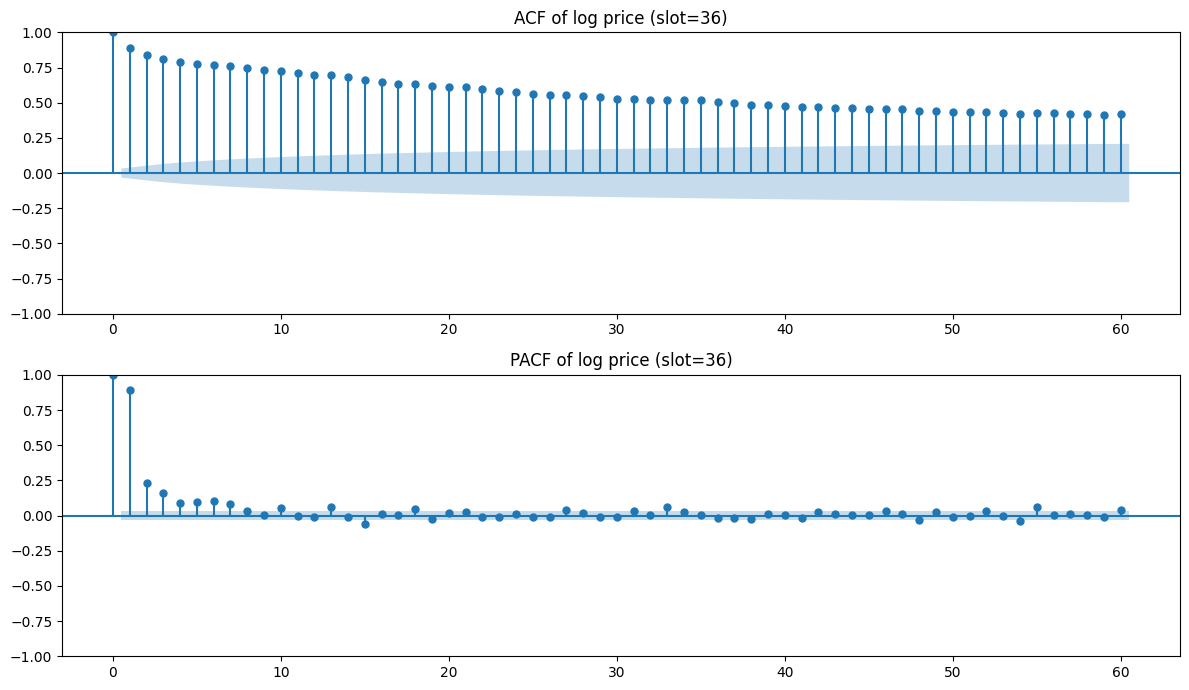

In [21]:
# slot 36 のみ
df36 = tokyo[tokyo["slot"] == 36].copy()

# 対数価格
df36["log_price"] = np.log(df36["price_scaled"])

# ACF / PACF
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

plot_acf(df36["log_price"], lags=60, ax=axes[0])
axes[0].set_title("ACF of log price (slot=36)")

plot_pacf(df36["log_price"], lags=60, ax=axes[1], method="ywm")
axes[1].set_title("PACF of log price (slot=36)")

plt.tight_layout()
plt.show()

- 真の短期自己相関
- 夏冬季節性

が混ざっているように見える

季節性を除去した残差でもう一度自己回帰係数を見てみると、短期自己相関がより顕著に見えるはず。

$$
\text{ma30}_t = \frac{1}{30} \sum_{i=0}^{29} S_{t-i}
$$

で30日の長期トレンドを計算し、残差を計算する
$$ 
\text{res}_t = \log S_t - \log \text{ma30}_t
$$

In [ ]:
df36["ma30"] = df36["log_price"].rolling(30, center=True).mean()

df36["resid"] = df36["log_price"] - df36["ma30"]

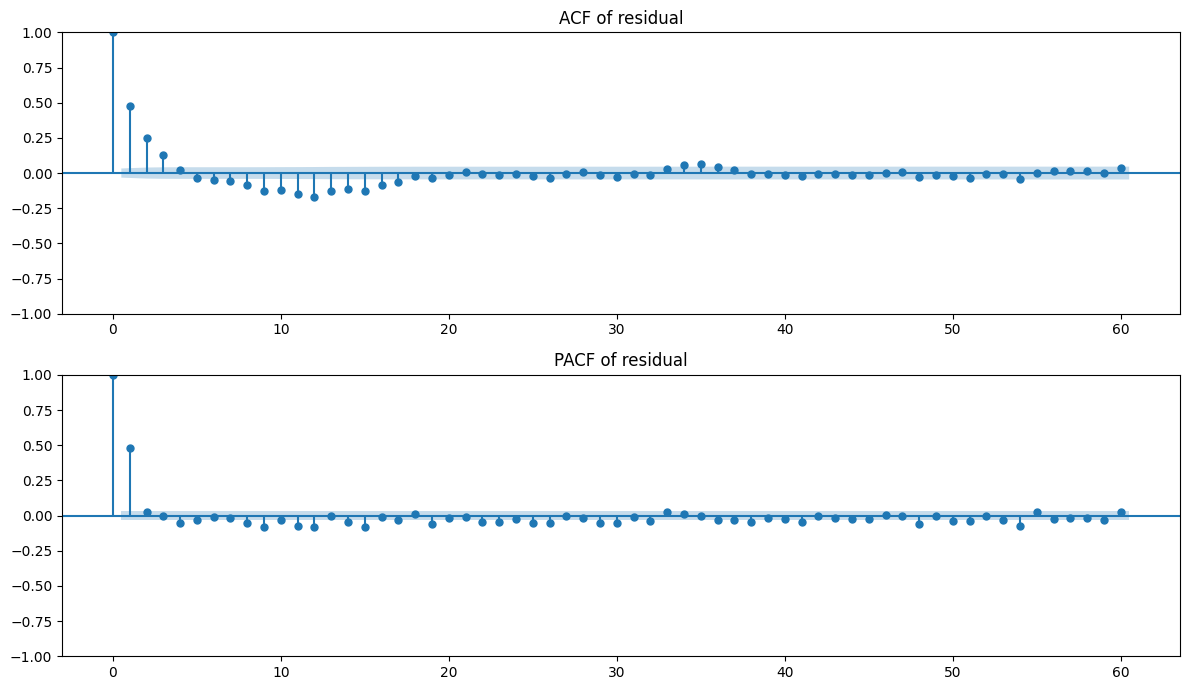

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

plot_acf(df36["resid"].dropna(), lags=60, ax=axes[0])

axes[0].set_title("ACF of residual")

plot_pacf(df36["resid"].dropna(), lags=60, ax=axes[1], method="ywm")

axes[1].set_title("PACF of residual")

plt.tight_layout()
plt.show()

In [28]:
y_col = "log_price"

results = []

for p in range(1, 15):
    data = df36[[y_col]].copy()

    for lag in range(1, p + 1):
        data[f"log_price_lag{lag}"] = data[y_col].shift(lag)

    data = data.dropna()

    X_cols = [f"log_price_lag{lag}" for lag in range(1, p + 1)]

    X = sm.add_constant(data[X_cols])
    y = data[y_col]

    model = sm.OLS(y, X).fit()

    results.append({
        "p": p,
        "AIC": model.aic,
        "BIC": model.bic,
        "Adj_R2": model.rsquared_adj,
    })

ic_table = pd.DataFrame(results)

ic_table

,p,AIC,BIC,Adj_R2
0,1,-224.001218,-211.595705,0.793950
1,2,-423.141246,-404.533799,0.804938
2,3,-517.571595,-492.762761,0.809950
3,4,-544.937356,-513.927684,0.811433
4,5,-576.560422,-539.350461,0.813102
5,6,-613.101023,-569.691321,0.814969
6,7,-633.264892,-583.655998,0.816053
7,8,-634.630391,-578.822856,0.816185
8,9,-631.644457,-569.638829,0.816086
9,10,-640.662393,-572.459222,0.816640


In [29]:
print("BIC minimum:")
display(ic_table.loc[[ic_table["BIC"].idxmin()]])

BIC minimum:


,p,AIC,BIC,Adj_R2
6,7,-633.264892,-583.655998,0.816053


In [ ]:
y_col = "log_price"

# -------------------
# Model A : lag 1 & 7
# -------------------
model_a = df36[[y_col]].copy()

for lag in [1, 7]:
    model_a[f"lag{lag}"] = model_a[y_col].shift(lag)

model_a = model_a.dropna()

X_a = sm.add_constant(model_a[["lag1", "lag7"]])

y_a = model_a[y_col]

fit_a = sm.OLS(y_a, X_a).fit()

# -------------------
# Model B : lag 1-7
# -------------------
model_b = df36[[y_col]].copy()

for lag in range(1, 8):
    model_b[f"lag{lag}"] = model_b[y_col].shift(lag)

model_b = model_b.dropna()

X_b = sm.add_constant(model_b[[f"lag{i}" for i in range(1, 8)]])

y_b = model_b[y_col]

fit_b = sm.OLS(y_b, X_b).fit()

# -------------------
# Compare
# -------------------
comparison = {
    "Model": ["lag1+7", "lag1-7"],
    "AIC": [fit_a.aic, fit_b.aic],
    "BIC": [fit_a.bic, fit_b.bic],
    "Adj_R2": [fit_a.rsquared_adj, fit_b.rsquared_adj],
}
pd.DataFrame(comparison)

,Model,AIC,BIC,Adj_R2
0,lag1+7,-484.754176,-466.150841,0.808141
1,lag1-7,-633.264892,-583.655998,0.816053


# 1week data

In [5]:
weekly_base = pd.read_csv((PROJECT_DATA_DIR / "processed/electricity/weekly_base.csv"))
weekly_base["datetime"] = pd.to_datetime(weekly_base["datetime"])

weekly_base = weekly_base.set_index("datetime")
weekly_base = weekly_base.asfreq("W")

weekly_base.head()

,tokyo_price,log_tokyo_price
datetime,,
2016-04-03,7.061875,1.954711
2016-04-10,7.583363,2.025957
2016-04-17,7.936190,2.071433
2016-04-24,7.734077,2.045636
2016-05-01,10.593512,2.360242


In [6]:
weekly_base.tail()

,tokyo_price,log_tokyo_price
datetime,,
2026-03-08,10.822143,2.381594
2026-03-15,13.878214,2.630320
2026-03-22,16.710030,2.816009
2026-03-29,15.895655,2.766046
2026-04-05,18.612292,2.923822


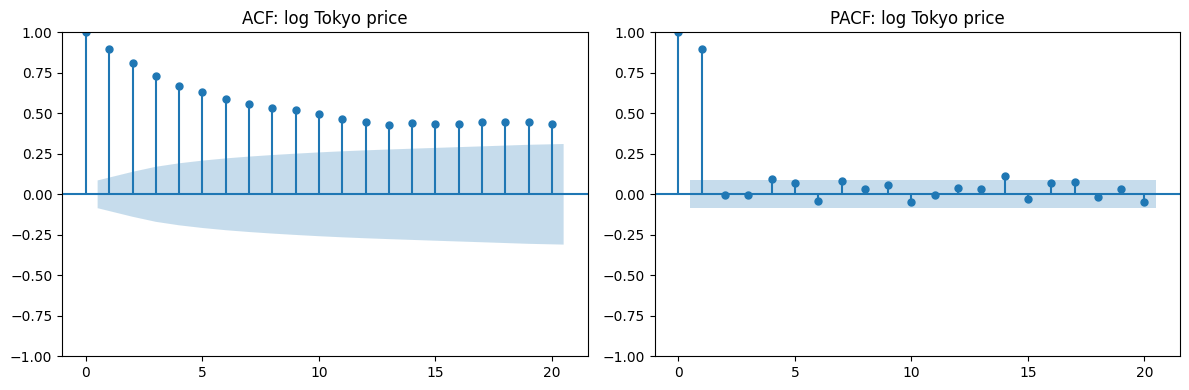

In [7]:
y = weekly_base["log_tokyo_price"].dropna()
# ACFとPACFのプロット
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(y, lags=20, ax=axes[0])
axes[0].set_title("ACF: log Tokyo price")

plot_pacf(y, lags=20, ax=axes[1], method="ywm")
axes[1].set_title("PACF: log Tokyo price")

plt.tight_layout()
plt.show()

In [8]:
# AR(1)を推定
ar1_model = AutoReg(y, lags=1, old_names=False)
ar1_res = ar1_model.fit()

print(ar1_res.summary())

                            AutoReg Model Results                             
Dep. Variable:        log_tokyo_price   No. Observations:                  523
Model:                     AutoReg(1)   Log Likelihood                 137.353
Method:               Conditional MLE   S.D. of innovations              0.186
Date:                Sun, 24 May 2026   AIC                           -268.706
Time:                        11:23:59   BIC                           -255.933
Sample:                    04-10-2016   HQIC                          -263.703
                         - 04-05-2026                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.2391      0.047      5.133      0.000       0.148       0.330
log_tokyo_price.L1     0.9024      0.019     47.833      0.000       0.865       0.939
                    

In [9]:
# AR(p), p=1,...,8 のAIC/BIC比較
ic_results = []

for p in range(1, 9):
    model = AutoReg(y, lags=p, old_names=False)
    res = model.fit()

    ic_results.append({"p": p, "AIC": res.aic, "BIC": res.bic, "HQIC": res.hqic})

ic_table = pd.DataFrame(ic_results)

ic_table

,p,AIC,BIC,HQIC
0,1,-268.705710,-255.932707,-263.702865
1,2,-265.219778,-248.196778,-258.551770
2,3,-261.699708,-240.430564,-253.367769
3,4,-262.746152,-237.234729,-252.751520
4,5,-263.514547,-233.764721,-251.858462
5,6,-262.690335,-228.705992,-249.374042
6,7,-262.985801,-224.770840,-248.010550
7,8,-260.059739,-217.618070,-243.426785


In [10]:
best_p_bic = int(ic_table.loc[ic_table["BIC"].idxmin(), "p"])
best_p_aic = int(ic_table.loc[ic_table["AIC"].idxmin(), "p"])

print("Best p by AIC:", best_p_aic)
print("Best p by BIC:", best_p_bic)

Best p by AIC: 1
Best p by BIC: 1


In [11]:
# BICで選んだモデルを推定
best_model = AutoReg(y, lags=best_p_bic, old_names=False)
best_res = best_model.fit()

print(best_res.summary())

                            AutoReg Model Results                             
Dep. Variable:        log_tokyo_price   No. Observations:                  523
Model:                     AutoReg(1)   Log Likelihood                 137.353
Method:               Conditional MLE   S.D. of innovations              0.186
Date:                Sun, 24 May 2026   AIC                           -268.706
Time:                        11:24:00   BIC                           -255.933
Sample:                    04-10-2016   HQIC                          -263.703
                         - 04-05-2026                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.2391      0.047      5.133      0.000       0.148       0.330
log_tokyo_price.L1     0.9024      0.019     47.833      0.000       0.865       0.939
                    

<Figure size 800x400 with 0 Axes>

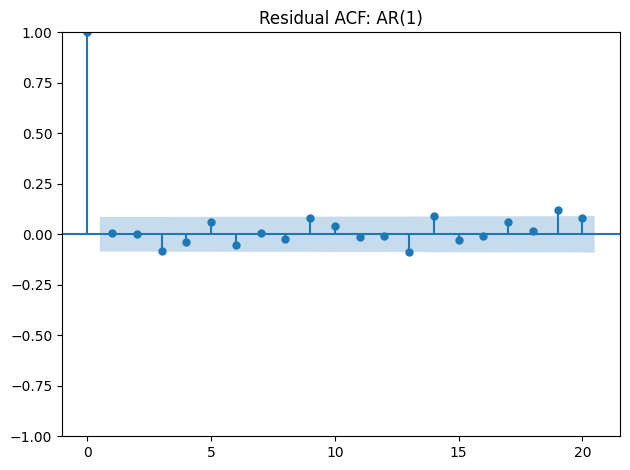

In [12]:
resid = best_res.resid

plt.figure(figsize=(8, 4))
plot_acf(resid, lags=20)
plt.title(f"Residual ACF: AR({best_p_bic})")
plt.tight_layout()
plt.show()

AR(2)で短期自己相関はかなり除去できている
が、周期的な構造が少し残っている

In [13]:
weekly_daytime = pd.read_csv(
    (PROJECT_DATA_DIR / "processed/electricity/weekly_daytime.csv")
)
weekly_daytime["datetime"] = pd.to_datetime(weekly_daytime["datetime"])

weekly_daytime = weekly_daytime.set_index("datetime")
weekly_daytime = weekly_daytime.asfreq("W")

weekly_daytime.head()

,tokyo_price,log_tokyo_price
datetime,,
2016-04-03,9.380952,2.238681
2016-04-10,8.811333,2.176039
2016-04-17,9.627619,2.264636
2016-04-24,9.952667,2.297841
2016-05-01,16.528476,2.805085


In [14]:
weekly_daytime.tail()

,tokyo_price,log_tokyo_price
datetime,,
2026-03-08,12.063524,2.490186
2026-03-15,12.784095,2.548202
2026-03-22,17.325143,2.852159
2026-03-29,16.534571,2.805453
2026-04-05,18.195714,2.901186


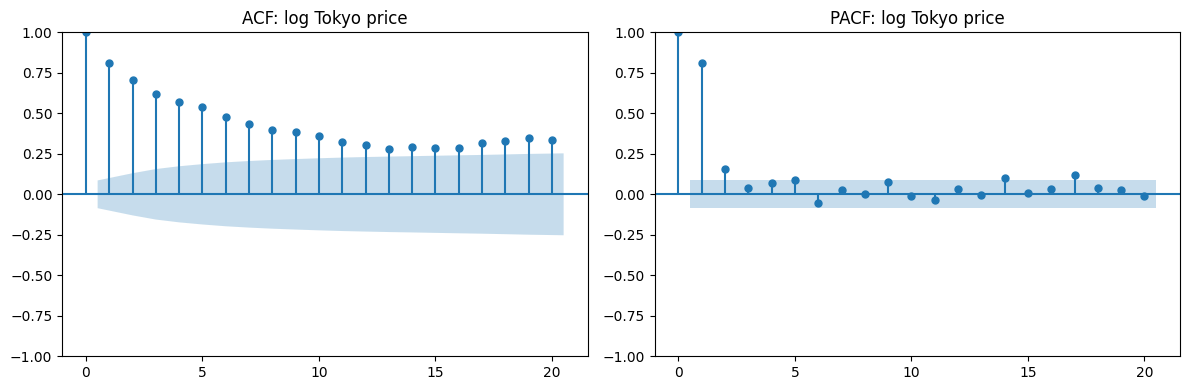

In [15]:
y = weekly_daytime["log_tokyo_price"].dropna()
# ACFとPACFのプロット
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(y, lags=20, ax=axes[0])
axes[0].set_title("ACF: log Tokyo price")

plot_pacf(y, lags=20, ax=axes[1], method="ywm")
axes[1].set_title("PACF: log Tokyo price")

plt.tight_layout()
plt.show()

In [16]:
# AR(p), p=1,...,8 のAIC/BIC比較
ic_results = []

for p in range(1, 9):
    model = AutoReg(y, lags=p, old_names=False)
    res = model.fit()

    ic_results.append({"p": p, "AIC": res.aic, "BIC": res.bic, "HQIC": res.hqic})

ic_table = pd.DataFrame(ic_results)

ic_table

,p,AIC,BIC,HQIC
0,1,144.399603,157.172606,149.402448
1,2,133.402735,150.425735,140.070743
2,3,135.432388,156.701532,143.764327
3,4,135.745301,161.256724,145.739933
4,5,131.822123,161.571949,143.478208
5,6,130.940956,164.925299,144.257249
6,7,133.281405,171.496366,148.256656
7,8,136.052866,178.494535,152.685821


In [17]:
best_p_bic = int(ic_table.loc[ic_table["BIC"].idxmin(), "p"])
best_p_aic = int(ic_table.loc[ic_table["AIC"].idxmin(), "p"])

print("Best p by AIC:", best_p_aic)
print("Best p by BIC:", best_p_bic)

Best p by AIC: 6
Best p by BIC: 2


In [18]:
# BICで選んだモデルを推定
best_model = AutoReg(y, lags=best_p_bic, old_names=False)
best_res = best_model.fit()

print(best_res.summary())

                            AutoReg Model Results                             
Dep. Variable:        log_tokyo_price   No. Observations:                  523
Model:                     AutoReg(2)   Log Likelihood                 -62.701
Method:               Conditional MLE   S.D. of innovations              0.273
Date:                Sun, 24 May 2026   AIC                            133.403
Time:                        11:24:00   BIC                            150.426
Sample:                    04-17-2016   HQIC                           140.071
                         - 04-05-2026                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.4094      0.069      5.939      0.000       0.274       0.544
log_tokyo_price.L1     0.6793      0.043     15.706      0.000       0.594       0.764
log_tokyo_price.L2  

<Figure size 800x400 with 0 Axes>

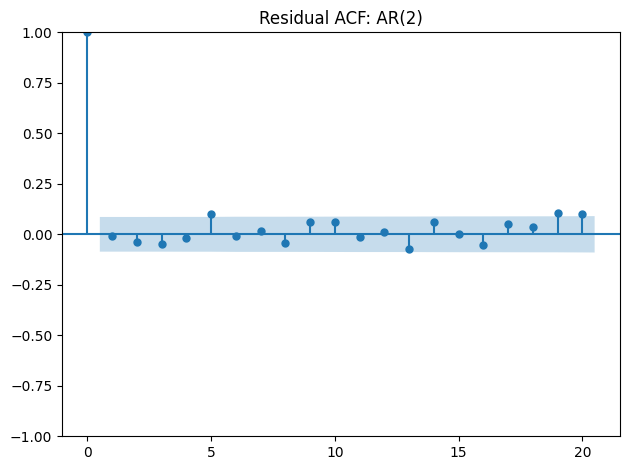

In [19]:
resid = best_res.resid

plt.figure(figsize=(8, 4))
plot_acf(resid, lags=20)
plt.title(f"Residual ACF: AR({best_p_bic})")
plt.tight_layout()
plt.show()